
## NIO Separatrix or instability identification


* Lorenz        → chaotic separatrix
* Duffing       → basin boundary
* Navier–Stokes → instability-generating vortex field


* Neural Input Optimization was applied to the 2-D Navier–Stokes equations to discover smooth initial vorticity configurations that maximize divergence between nearby trajectories, revealing instability-generating vortex structures.
* This animation shows the evolution of the optimized vorticity field discovered by Neural Input Optimization, revealing coherent vortex structures that generate strong divergence in the Navier–Stokes dynamics.


iter 0 loss 3.3595774173736572
iter 50 loss 4.19364595413208
iter 100 loss 4.151318550109863
iter 150 loss 4.103536128997803
iter 200 loss 4.043880939483643
iter 250 loss 3.965801954269409


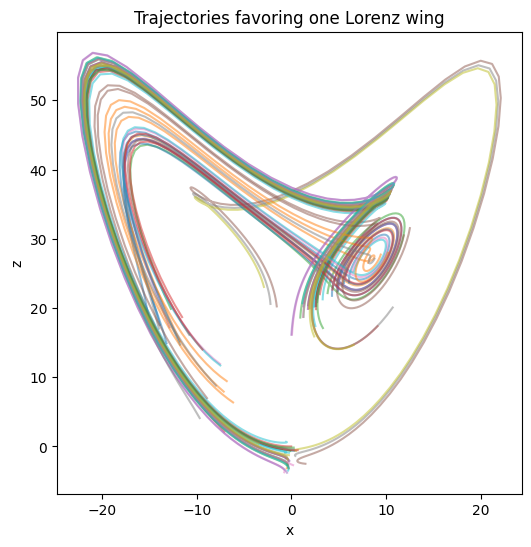

In [2]:


import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)

# -----------------------------
# Simple Lorenz one-step model
# -----------------------------
class LorenzStep(nn.Module):

    def __init__(self, dt=0.01):
        super().__init__()

        self.sigma = 10.0
        self.rho = 28.0
        self.beta = 8.0/3.0
        self.dt = dt

    def forward(self, x):

        X = x[:,0]
        Y = x[:,1]
        Z = x[:,2]

        dx = self.sigma*(Y - X)
        dy = X*(self.rho - Z) - Y
        dz = X*Y - self.beta*Z

        X = X + self.dt*dx
        Y = Y + self.dt*dy
        Z = Z + self.dt*dz

        return torch.stack([X,Y,Z],dim=1)


model = LorenzStep()

# -----------------------------------
# Multiple initial conditions (NIO)
# -----------------------------------

n_points = 50

x0 = torch.randn(n_points,3,requires_grad=True)

optimizer = optim.Adam([x0], lr=0.05)

T = 100
iters = 300


# -----------------------------------
# Optimization
# -----------------------------------

for i in range(iters):

    x = x0
    traj = []

    for t in range(T):

        x = model(x)
        traj.append(x)

    traj = torch.stack(traj)      # shape (T, N, 3)

    # encourage staying on positive wing (x > 0)
    ## loss = torch.relu(-traj[:,:,0]).mean()
    
    
    target_sign = 1   # +1 right wing, -1 left wing
    loss        = torch.relu(-target_sign * traj[:,:,0]).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 50 == 0:
        print("iter",i,"loss",loss.item())


# -----------------------------------
# Visualize trajectories
# -----------------------------------

traj_np = traj.detach().numpy()

plt.figure(figsize=(6,6))

for i in range(n_points):
    plt.plot(traj_np[:,i,0],traj_np[:,i,2],alpha=0.5)

plt.xlabel("x")
plt.ylabel("z")
plt.title("Trajectories favoring one Lorenz wing")

plt.show()






iter 0 loss 3.4167938232421875
iter 50 loss 4.230801105499268
iter 100 loss 4.1866559982299805
iter 150 loss 4.182676792144775
iter 200 loss 4.128374099731445
iter 250 loss 4.058876037597656


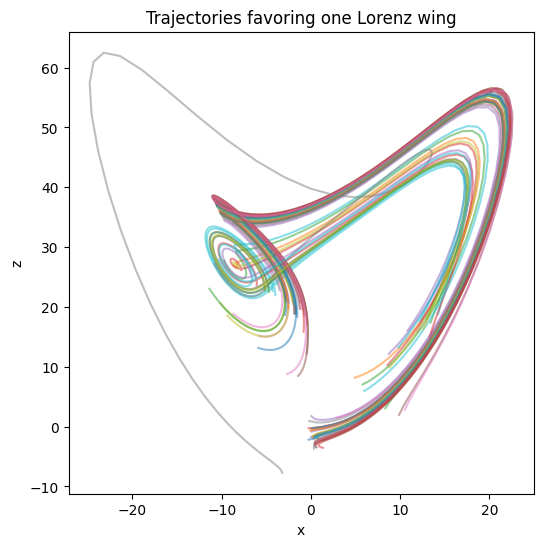

In [3]:


import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)

# -----------------------------
# Simple Lorenz one-step model
# -----------------------------
class LorenzStep(nn.Module):

    def __init__(self, dt=0.01):
        super().__init__()

        self.sigma = 10.0
        self.rho = 28.0
        self.beta = 8.0/3.0
        self.dt = dt

    def forward(self, x):

        X = x[:,0]
        Y = x[:,1]
        Z = x[:,2]

        dx = self.sigma*(Y - X)
        dy = X*(self.rho - Z) - Y
        dz = X*Y - self.beta*Z

        X = X + self.dt*dx
        Y = Y + self.dt*dy
        Z = Z + self.dt*dz

        return torch.stack([X,Y,Z],dim=1)


model = LorenzStep()

# -----------------------------------
# Multiple initial conditions (NIO)
# -----------------------------------

n_points = 50

x0 = torch.randn(n_points,3,requires_grad=True)

optimizer = optim.Adam([x0], lr=0.05)

T = 100
iters = 300


# -----------------------------------
# Optimization
# -----------------------------------

for i in range(iters):

    x = x0
    traj = []

    for t in range(T):

        x = model(x)
        traj.append(x)

    traj = torch.stack(traj)      # shape (T, N, 3)

    target_sign = -1   # +1 right wing, -1 left wing
    loss        = torch.relu(-target_sign * traj[:,:,0]).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 50 == 0:
        print("iter",i,"loss",loss.item())


# -----------------------------------
# Visualize trajectories
# -----------------------------------

traj_np = traj.detach().numpy()

plt.figure(figsize=(6,6))

for i in range(n_points):
    plt.plot(traj_np[:,i,0],traj_np[:,i,2],alpha=0.5)

plt.xlabel("x")
plt.ylabel("z")
plt.title("Trajectories favoring one Lorenz wing")

plt.show()







## The Separatrix

* area were slight variation has high impact on rest of evolution 
* Neural Input Optimization can recover invariant structures in chaotic dynamical systems using only a differentiable simulator
* NIO discovers regions of maximal trajectory sensitivity, which correspond to separatrix structures
* The separatrix is not something that happens at step 500
* It is a boundary in the initial condition space. So it exists at step 0.


iter 0 loss -2.554109573364258
iter 50 loss -0.002727367915213108
iter 100 loss -0.002770049264654517
iter 150 loss -0.0031930250115692616
iter 200 loss -0.002117197960615158
iter 250 loss -0.0021354530472308397


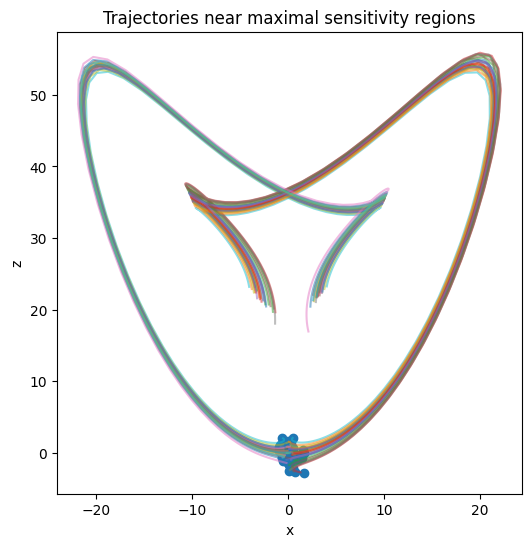

In [5]:

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)

# -----------------------------
# Simple Lorenz one-step model
# -----------------------------
class LorenzStep(nn.Module):

    def __init__(self, dt=0.01):
        super().__init__()

        self.sigma = 10.0
        self.rho = 28.0
        self.beta = 8.0/3.0
        self.dt = dt

    def forward(self, x):

        X = x[:,0]
        Y = x[:,1]
        Z = x[:,2]

        dx = self.sigma*(Y - X)
        dy = X*(self.rho - Z) - Y
        dz = X*Y - self.beta*Z

        X = X + self.dt*dx
        Y = Y + self.dt*dy
        Z = Z + self.dt*dz

        return torch.stack([X,Y,Z],dim=1)


model = LorenzStep()

# -----------------------------------
# Multiple initial conditions (NIO)
# -----------------------------------

n_points = 50

x0 = torch.randn(n_points,3,requires_grad=True)

optimizer = optim.Adam([x0], lr=0.05)

T = 100
iters = 300

eps = 1e-3   # tiny perturbation

# -----------------------------------
# Optimization
# -----------------------------------

for i in range(iters):

    xA = x0
    xB = x0 + eps

    trajA = []
    trajB = []

    for t in range(T):

        xA = model(xA)
        xB = model(xB)

        trajA.append(xA)
        trajB.append(xB)

    trajA = torch.stack(trajA)
    trajB = torch.stack(trajB)

    # -----------------------------------
    # sensitivity objective
    # maximize trajectory divergence
    # -----------------------------------
    loss = -torch.mean((trajA - trajB)**2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 50 == 0:
        print("iter",i,"loss",loss.item())


# -----------------------------------
# Visualize trajectories
# -----------------------------------

traj_np = trajA.detach().numpy()

plt.figure(figsize=(6,6))

for i in range(n_points):
    plt.plot(traj_np[:,i,0],traj_np[:,i,2],alpha=0.5)
    
plt.scatter(x0[:,0].detach(), x0[:,2].detach())

plt.xlabel("x")
plt.ylabel("z")
plt.title("Trajectories near maximal sensitivity regions")

plt.show()



## pendulum 


iter 0 loss -0.003740851301699877
iter 50 loss -0.23958386480808258
iter 100 loss -0.01608223281800747
iter 150 loss -0.007706007920205593
iter 200 loss -0.010109525173902512
iter 250 loss -0.008430926129221916


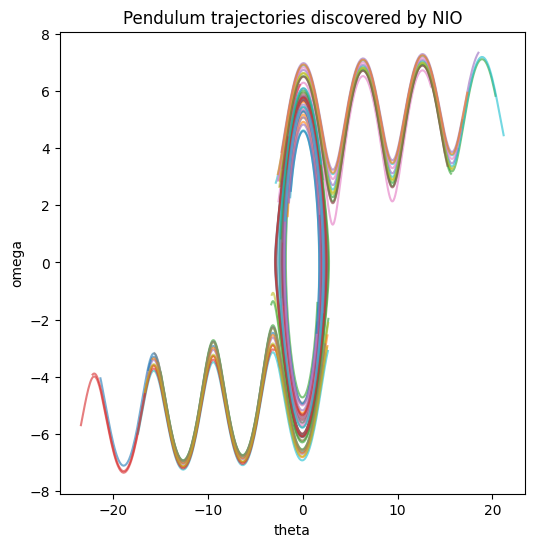

In [6]:

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)

# --------------------------------
# Pendulum one-step model
# --------------------------------

class PendulumStep(nn.Module):

    def __init__(self, dt=0.02):
        super().__init__()

        self.g  = 9.81
        self.L  = 1.0
        self.dt = dt

    def forward(self, x):

        theta = x[:,0]
        omega = x[:,1]

        dtheta = omega
        domega = -(self.g/self.L) * torch.sin(theta)

        theta = theta + self.dt*dtheta
        omega = omega + self.dt*domega

        return torch.stack([theta,omega],dim=1)


model = PendulumStep()

# --------------------------------
# Initial conditions (NIO variables)
# --------------------------------

n_points = 50

x0 = torch.randn(n_points,2,requires_grad=True)

optimizer = optim.Adam([x0],lr=0.05)

T     = 200
iters = 300

eps = 0.01   # small perturbation

# --------------------------------
# Optimization
# --------------------------------

for i in range(iters):

    xA = x0
    xB = x0 + eps*torch.randn_like(x0)

    trajA = []
    trajB = []

    for t in range(T):

        xA = model(xA)
        xB = model(xB)

        trajA.append(xA)
        trajB.append(xB)

    trajA = torch.stack(trajA)   # (T,N,2)
    trajB = torch.stack(trajB)

    # maximize divergence
    loss = -((trajA - trajB)**2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 50 == 0:
        print("iter",i,"loss",loss.item())


# --------------------------------
# Visualize trajectories
# --------------------------------

traj_np = trajA.detach().numpy()

plt.figure(figsize=(6,6))

for i in range(n_points):
    plt.plot(traj_np[:,i,0],traj_np[:,i,1],alpha=0.6)

plt.xlabel("theta")
plt.ylabel("omega")
plt.title("Pendulum trajectories discovered by NIO")

plt.show()



## Duffing Oscillator


iter 0 loss -0.00020958975073881447
iter 50 loss -0.0009636468603275716
iter 100 loss -0.0007949778810143471
iter 150 loss -0.0005906270816922188
iter 200 loss -0.0006523455958813429
iter 250 loss -0.0009505808120593429


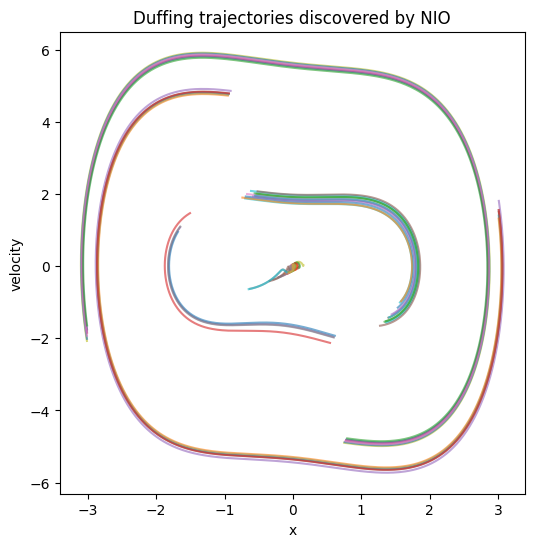

In [8]:

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)

# -----------------------------
# Duffing oscillator step model
# -----------------------------

class DuffingStep(nn.Module):

    def __init__(self, dt=0.005):
        super().__init__()

        self.delta = 0.2
        self.alpha = -1.0
        self.beta  = 1.0
        self.gamma = 0.3
        self.omega = 1.2

        self.dt = dt
        self.t  = 0.0

    def forward(self, x):

        pos = x[:,0]
        vel = x[:,1]

        force = self.gamma * torch.cos(torch.tensor(self.omega*self.t))

        dpos = vel
        dvel = (
            -self.delta*vel
            -self.alpha*pos
            -self.beta*(pos**3)
            + force
        )

        pos = pos + self.dt*dpos
        vel = vel + self.dt*dvel

        self.t += self.dt

        return torch.stack([pos,vel],dim=1)


model = DuffingStep()

# --------------------------------
# Initial conditions (NIO variables)
# --------------------------------

n_points = 50

x0 = torch.randn(n_points,2,requires_grad=True)

optimizer = optim.Adam([x0],lr=0.05)

T     = 400
iters = 300

eps = 0.01


# --------------------------------
# Optimization loop
# --------------------------------

for i in range(iters):

    model.t = 0.0

    xA = x0
    xB = x0 + eps*torch.randn_like(x0)

    trajA = []
    trajB = []

    for t in range(T):

        xA = model(xA)
        xB = model(xB)

        trajA.append(xA)
        trajB.append(xB)

    trajA = torch.stack(trajA)   # (T,N,2)
    trajB = torch.stack(trajB)

    # maximize divergence
    loss = -((trajA - trajB)**2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # keep initial conditions bounded
    with torch.no_grad():
        x0.clamp_(-3,3)

    if i % 50 == 0:
        print("iter",i,"loss",loss.item())


# --------------------------------
# Visualize trajectories
# --------------------------------

traj_np = trajA.detach().numpy()

plt.figure(figsize=(6,6))

for i in range(n_points):
    plt.plot(traj_np[:,i,0],traj_np[:,i,1],alpha=0.6)

plt.xlabel("x")
plt.ylabel("velocity")
plt.title("Duffing trajectories discovered by NIO")

plt.show()


iter 0 loss -0.00035678542917594314
iter 50 loss -0.0017557615647092462
iter 100 loss -0.0018150301184505224
iter 150 loss -0.0025111502036452293
iter 200 loss -0.0020617216359823942
iter 250 loss -0.0021287943236529827


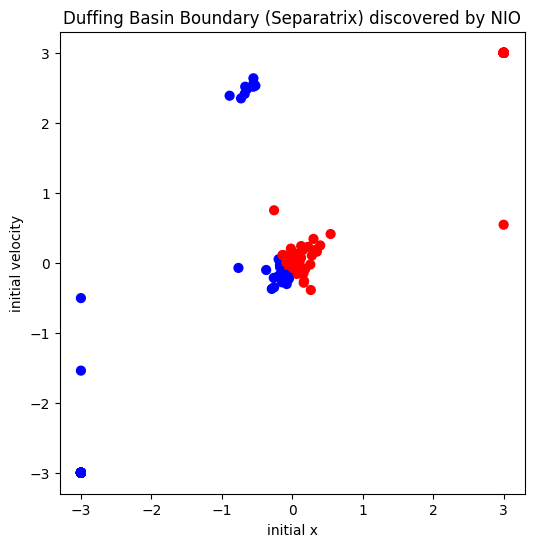

In [9]:

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)

# --------------------------------
# Duffing oscillator step model
# --------------------------------

class DuffingStep(nn.Module):

    def __init__(self, dt=0.005):
        super().__init__()

        self.delta = 0.2
        self.alpha = -1.0
        self.beta  = 1.0
        self.gamma = 0.3
        self.omega = 1.2

        self.dt = dt
        self.t  = 0.0

    def forward(self, x):

        pos = x[:,0]
        vel = x[:,1]

        force = self.gamma * torch.cos(torch.tensor(self.omega*self.t))

        dpos = vel
        dvel = (
            -self.delta*vel
            -self.alpha*pos
            -self.beta*(pos**3)
            + force
        )

        pos = pos + self.dt*dpos
        vel = vel + self.dt*dvel

        self.t += self.dt

        return torch.stack([pos,vel],dim=1)


model = DuffingStep()

# --------------------------------
# Initial conditions (NIO)
# --------------------------------

n_points = 200

x0 = torch.randn(n_points,2,requires_grad=True)

optimizer = optim.Adam([x0],lr=0.05)

T = 600
iters = 300
eps = 0.01


# --------------------------------
# Optimization
# --------------------------------

for i in range(iters):

    model.t = 0.0

    xA = x0
    xB = x0 + eps*torch.randn_like(x0)

    trajA = []
    trajB = []

    for t in range(T):

        xA = model(xA)
        xB = model(xB)

        trajA.append(xA)
        trajB.append(xB)

    trajA = torch.stack(trajA)
    trajB = torch.stack(trajB)

    loss = -((trajA - trajB)**2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        x0.clamp_(-3,3)

    if i % 50 == 0:
        print("iter",i,"loss",loss.item())


# --------------------------------
# Determine attractor for each IC
# --------------------------------

model.t = 0.0

x = x0.detach()

for t in range(T):
    x = model(x)

final_pos = x[:,0].numpy()
initial = x0.detach().numpy()

colors = []

for v in final_pos:
    if v > 0:
        colors.append("red")
    else:
        colors.append("blue")


# --------------------------------
# Plot basin boundary (separatrix)
# --------------------------------

plt.figure(figsize=(6,6))

plt.scatter(
    initial[:,0],
    initial[:,1],
    c=colors,
    s=40
)

plt.xlabel("initial x")
plt.ylabel("initial velocity")
plt.title("Duffing Basin Boundary (Separatrix) discovered by NIO")

plt.show()



## Simplified Navier Stokes


iter 0 loss 0.4023379683494568 divergence 2.1807099983561784e-05
iter 25 loss 0.09813661128282547 divergence 1.9712848370545544e-05
iter 50 loss 0.026286674663424492 divergence 1.9432403860264458e-05
iter 75 loss 0.008673060685396194 divergence 1.846083796408493e-05
iter 100 loss 0.003525500651448965 divergence 1.7470809325459413e-05
iter 125 loss 0.0017001461237668991 divergence 1.830647852330003e-05
iter 150 loss 0.0009265051339752972 divergence 1.816311305447016e-05
iter 175 loss 0.0005505027947947383 divergence 1.794499075913336e-05


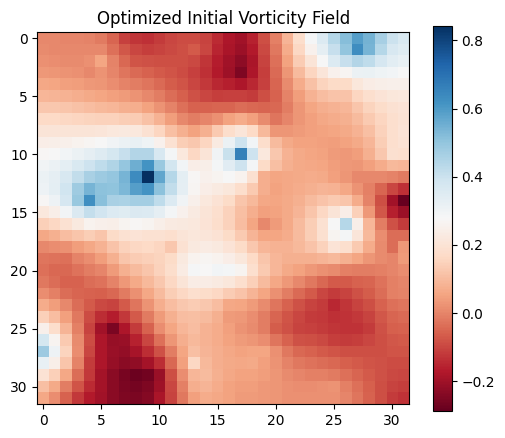

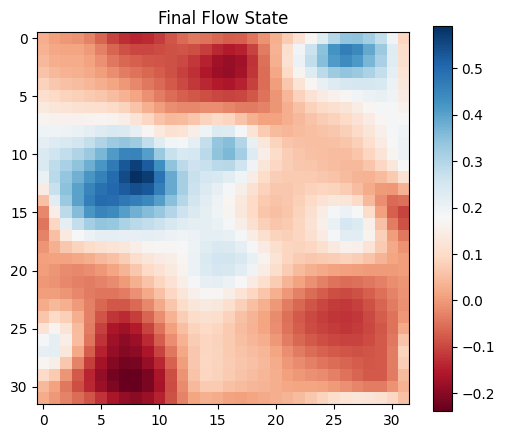

In [12]:

import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)

# -----------------------------
# simulation parameters
# -----------------------------

N = 32
L = 2*np.pi
dx = L/N
dt = 0.01
nu = 0.01

# -----------------------------
# spectral wave numbers
# -----------------------------

k = torch.fft.fftfreq(N, d=dx/(2*np.pi))
kx, ky = torch.meshgrid(k, k, indexing="ij")

lap = -(kx**2 + ky**2)
lap[0,0] = 1.0

# -----------------------------
# Navier–Stokes step
# -----------------------------

def step(w):

    w_hat = torch.fft.fft2(w)

    psi_hat = -w_hat / lap

    psi = torch.real(torch.fft.ifft2(psi_hat))

    u = torch.real(torch.fft.ifft2(1j*ky*psi_hat))
    v = torch.real(torch.fft.ifft2(-1j*kx*psi_hat))

    w_x = torch.real(torch.fft.ifft2(1j*kx*w_hat))
    w_y = torch.real(torch.fft.ifft2(1j*ky*w_hat))

    adv = u*w_x + v*w_y

    diff = nu * torch.real(torch.fft.ifft2(lap*w_hat))

    return w + dt*(-adv + diff)

# -----------------------------
# smoothness prior
# -----------------------------

def smoothness(w):
    return ((w[:,:,:-1]-w[:,:,1:])**2).mean() + ((w[:,:-1,:]-w[:,1:,:])**2).mean()

# -----------------------------
# NIO initial vorticity fields
# -----------------------------

n_fields = 10

w0 = torch.randn(n_fields,N,N,requires_grad=True)

optimizer = optim.Adam([w0],lr=0.03)

T = 300
iters = 200
eps = 0.01

# -----------------------------
# optimization loop
# -----------------------------

for i in range(iters):

    wA = w0
    wB = w0 + eps*torch.randn_like(w0)

    trajA=[]
    trajB=[]

    for t in range(T):

        wA = step(wA)
        wB = step(wB)

        trajA.append(wA)
        trajB.append(wB)

    trajA = torch.stack(trajA)
    trajB = torch.stack(trajB)

    divergence = ((trajA-trajB)**2).mean()

    loss = -divergence + 0.1*smoothness(w0)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        w0.clamp_(-5,5)

    if i % 25 == 0:
        print("iter",i,"loss",loss.item(),"divergence",divergence.item())

# -----------------------------
# visualize optimized vorticity
# -----------------------------

w_init = w0.detach().numpy()

plt.figure(figsize=(6,5))

plt.imshow(w_init[0],cmap="RdBu")
plt.colorbar()
plt.title("Optimized Initial Vorticity Field")

plt.show()

# -----------------------------
# simulate final trajectory
# -----------------------------

w = torch.tensor(w_init[0])

trajectory=[]

for t in range(200):

    w = step(w)
    trajectory.append(w.detach().numpy())

trajectory = np.array(trajectory)

plt.figure(figsize=(6,5))
plt.imshow(trajectory[-1],cmap="RdBu")
plt.colorbar()
plt.title("Final Flow State")
plt.show()


In [15]:

## !pip install imageio


iter 0 loss 0.4023379683494568 divergence 2.1807099983561784e-05
iter 25 loss 0.09813661128282547 divergence 1.9712848370545544e-05
iter 50 loss 0.026286674663424492 divergence 1.9432403860264458e-05
iter 75 loss 0.008673060685396194 divergence 1.846083796408493e-05
iter 100 loss 0.003525500651448965 divergence 1.7470809325459413e-05
iter 125 loss 0.0017001461237668991 divergence 1.830647852330003e-05
iter 150 loss 0.0009265051339752972 divergence 1.816311305447016e-05
iter 175 loss 0.0005505027947947383 divergence 1.794499075913336e-05


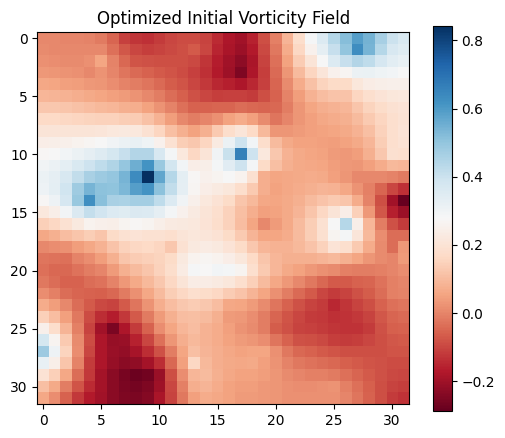

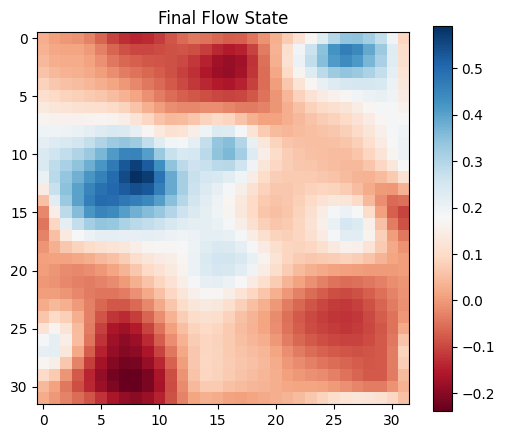

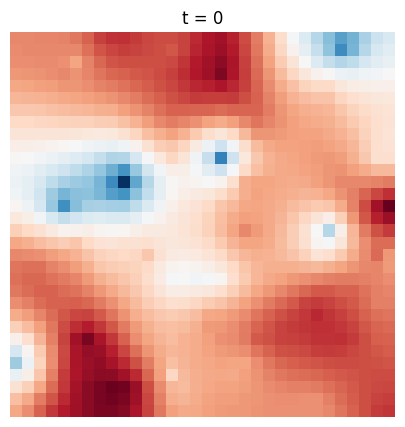

In [23]:

import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation

torch.manual_seed(0)

# -----------------------------
# simulation parameters
# -----------------------------

N = 32
L = 2*np.pi
dx = L/N
dt = 0.01
nu = 0.01

# -----------------------------
# spectral wave numbers
# -----------------------------

k = torch.fft.fftfreq(N, d=dx/(2*np.pi))
kx, ky = torch.meshgrid(k, k, indexing="ij")

lap = -(kx**2 + ky**2)
lap[0,0] = 1.0

# -----------------------------
# Navier–Stokes step
# -----------------------------

def step(w):

    w_hat = torch.fft.fft2(w)

    psi_hat = -w_hat / lap

    psi = torch.real(torch.fft.ifft2(psi_hat))

    u = torch.real(torch.fft.ifft2(1j*ky*psi_hat))
    v = torch.real(torch.fft.ifft2(-1j*kx*psi_hat))

    w_x = torch.real(torch.fft.ifft2(1j*kx*w_hat))
    w_y = torch.real(torch.fft.ifft2(1j*ky*w_hat))

    adv = u*w_x + v*w_y
    diff = nu * torch.real(torch.fft.ifft2(lap*w_hat))

    return w + dt*(-adv + diff)

# -----------------------------
# smoothness prior
# -----------------------------

def smoothness(w):
    return ((w[:,:,:-1]-w[:,:,1:])**2).mean() + ((w[:,:-1,:]-w[:,1:,:])**2).mean()

# -----------------------------
# NIO initial vorticity fields
# -----------------------------

n_fields = 10
w0 = torch.randn(n_fields,N,N,requires_grad=True)

optimizer = optim.Adam([w0],lr=0.03)

T = 300
iters = 200
eps = 0.01

# -----------------------------
# optimization loop
# -----------------------------

for i in range(iters):

    wA = w0
    wB = w0 + eps*torch.randn_like(w0)

    trajA=[]
    trajB=[]

    for t in range(T):

        wA = step(wA)
        wB = step(wB)

        trajA.append(wA)
        trajB.append(wB)

    trajA = torch.stack(trajA)
    trajB = torch.stack(trajB)

    divergence = ((trajA-trajB)**2).mean()

    loss = -divergence + 0.1*smoothness(w0)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        w0.clamp_(-5,5)

    if i % 25 == 0:
        print("iter",i,"loss",loss.item(),"divergence",divergence.item())

# -----------------------------
# visualize optimized vorticity
# -----------------------------

w_init = w0.detach().numpy()

plt.figure(figsize=(6,5))
plt.imshow(w_init[0],cmap="RdBu")
plt.colorbar()
plt.title("Optimized Initial Vorticity Field")
plt.show()

# -----------------------------
# simulate final trajectory
# -----------------------------

w = torch.tensor(w_init[0])

trajectory=[]

for t in range(200):

    w = step(w)
    trajectory.append(w.detach().numpy())

trajectory = np.array(trajectory)

plt.figure(figsize=(6,5))
plt.imshow(trajectory[-1],cmap="RdBu")
plt.colorbar()
plt.title("Final Flow State")
plt.show()

# -----------------------------
# ANIMATION (does not change dynamics)
# -----------------------------

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(trajectory[0], cmap="RdBu")
ax.set_title("Navier-Stokes Evolution")
ax.axis("off")

def update(frame):
    im.set_data(trajectory[frame])
    ax.set_title(f"t = {frame}")
    return [im]

anim = FuncAnimation(
    fig,
    update,
    frames=len(trajectory),
    interval=50,
    blit=True
)

plt.show()


In [24]:

anim.save("navier_stokes.gif", writer="pillow")


iter 0 loss 0.4023379683494568 divergence 2.1807099983561784e-05
iter 25 loss 0.09813661128282547 divergence 1.9712848370545544e-05
iter 50 loss 0.026286674663424492 divergence 1.9432403860264458e-05
iter 75 loss 0.008673060685396194 divergence 1.846083796408493e-05
iter 100 loss 0.003525500651448965 divergence 1.7470809325459413e-05
iter 125 loss 0.0017001461237668991 divergence 1.830647852330003e-05
iter 150 loss 0.0009265051339752972 divergence 1.816311305447016e-05
iter 175 loss 0.0005505027947947383 divergence 1.794499075913336e-05


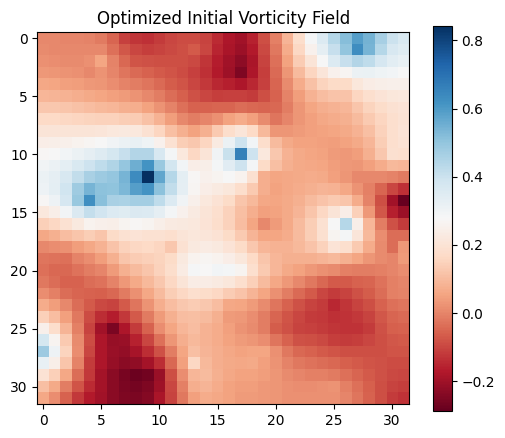

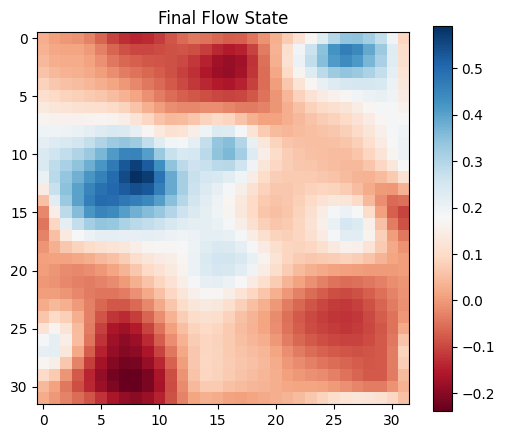

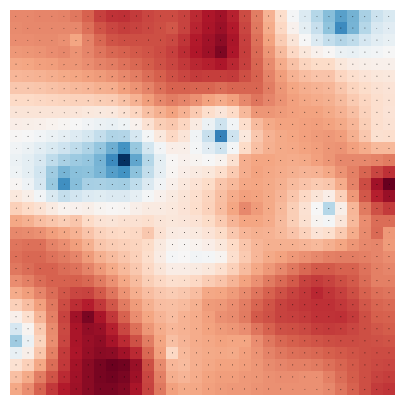

In [25]:

import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation

torch.manual_seed(0)

# -----------------------------
# simulation parameters
# -----------------------------

N = 32
L = 2*np.pi
dx = L/N
dt = 0.01
nu = 0.01

# -----------------------------
# spectral wave numbers
# -----------------------------

k = torch.fft.fftfreq(N, d=dx/(2*np.pi))
kx, ky = torch.meshgrid(k, k, indexing="ij")

lap = -(kx**2 + ky**2)
lap[0,0] = 1.0

# -----------------------------
# Navier–Stokes step
# -----------------------------

def step(w):

    w_hat = torch.fft.fft2(w)

    psi_hat = -w_hat / lap

    psi = torch.real(torch.fft.ifft2(psi_hat))

    u = torch.real(torch.fft.ifft2(1j*ky*psi_hat))
    v = torch.real(torch.fft.ifft2(-1j*kx*psi_hat))

    w_x = torch.real(torch.fft.ifft2(1j*kx*w_hat))
    w_y = torch.real(torch.fft.ifft2(1j*ky*w_hat))

    adv = u*w_x + v*w_y
    diff = nu * torch.real(torch.fft.ifft2(lap*w_hat))

    return w + dt*(-adv + diff)

# -----------------------------
# smoothness prior
# -----------------------------

def smoothness(w):
    return ((w[:,:,:-1]-w[:,:,1:])**2).mean() + ((w[:,:-1,:]-w[:,1:,:])**2).mean()

# -----------------------------
# NIO initial vorticity fields
# -----------------------------

n_fields = 10
w0 = torch.randn(n_fields,N,N,requires_grad=True)

optimizer = optim.Adam([w0],lr=0.03)

T = 300
iters = 200
eps = 0.01

# -----------------------------
# optimization loop
# -----------------------------

for i in range(iters):

    wA = w0
    wB = w0 + eps*torch.randn_like(w0)

    trajA=[]
    trajB=[]

    for t in range(T):

        wA = step(wA)
        wB = step(wB)

        trajA.append(wA)
        trajB.append(wB)

    trajA = torch.stack(trajA)
    trajB = torch.stack(trajB)

    divergence = ((trajA-trajB)**2).mean()

    loss = -divergence + 0.1*smoothness(w0)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        w0.clamp_(-5,5)

    if i % 25 == 0:
        print("iter",i,"loss",loss.item(),"divergence",divergence.item())

# -----------------------------
# visualize optimized vorticity
# -----------------------------

w_init = w0.detach().numpy()

plt.figure(figsize=(6,5))
plt.imshow(w_init[0],cmap="RdBu")
plt.colorbar()
plt.title("Optimized Initial Vorticity Field")
plt.show()

# -----------------------------
# simulate final trajectory
# -----------------------------

w = torch.tensor(w_init[0])

trajectory=[]

for t in range(200):

    w = step(w)
    trajectory.append(w.detach().numpy())

trajectory = np.array(trajectory)

plt.figure(figsize=(6,5))
plt.imshow(trajectory[-1],cmap="RdBu")
plt.colorbar()
plt.title("Final Flow State")
plt.show()

# -----------------------------
# compute velocity field for visualization
# -----------------------------

def velocity_from_vorticity(w):

    w_hat = torch.fft.fft2(torch.tensor(w))

    psi_hat = -w_hat / lap

    u = torch.real(torch.fft.ifft2(1j*ky*psi_hat)).numpy()
    v = torch.real(torch.fft.ifft2(-1j*kx*psi_hat)).numpy()

    return u,v

# grid for arrows
x = np.arange(N)
y = np.arange(N)

X,Y = np.meshgrid(x,y)

# -----------------------------
# animation
# -----------------------------

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(trajectory[0], cmap="RdBu")

u,v = velocity_from_vorticity(trajectory[0])

quiver = ax.quiver(
    X,Y,
    u,v,
    color="black",
    scale=50
)

ax.axis("off")

def update(frame):

    w = trajectory[frame]

    im.set_data(w)

    u,v = velocity_from_vorticity(w)

    quiver.set_UVC(u,v)

    ax.set_title(f"t = {frame}")

    return im,quiver

anim = FuncAnimation(
    fig,
    update,
    frames=len(trajectory),
    interval=40,
    blit=False
)

plt.show()


In [26]:

anim.save("navier_stokes_quiver.gif", writer="pillow")
